# Chemical Representation I - RDKit
In this lab, we will use the `rdkit` package to perform various cheminformatics tasks.

By the end of this lab, you will be able to:

1. Represent molecules using SMILES, canonical SMILES, InChI, and InChIKey.
2. Convert between representations programmatically.
3. Generate 3D geometries and export XYZ files.
4. Visualize molecules in 2D and 3D.
5. Use SMARTS to detect functional groups

In [ ]:
# install rdkit
!pip install -q rdkit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.4/36.4 MB 39.0 MB/s eta 0:00:00


In [ ]:
# Let's make a working directory (folder) since we are organized people
!mkdir -p rdkit_prac

In [ ]:
from rdkit import Chem
from rdkit.Chem import AllChem, Draw
from rdkit.Chem.Draw import IPythonConsole

## Creating a molecule from SMILES

The key in rdkit is a molecule object, usually represented with `mol`.

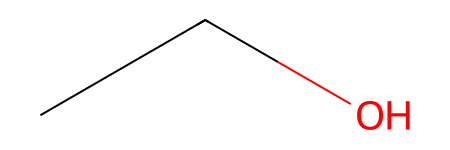

In [ ]:
smiles = "OCC" # ethanol
mol = Chem.MolFromSmiles(smiles) # build the molecule object in rdkit
# you could visualize the molecule by simply displaying mol
mol

In [ ]:
# Or more rigorously, call the Chem.Draw module to draw the molecule and save it
img = Draw.MolToImage(mol, size=(200, 200))
img.save("rdkit_prac/ethnol.png")


### Generating canonical SMILES
Generating canonical SMILES is simple: you map the `mol` object back to SMILES, with the option `canonical` equal to True.

In [ ]:
canonical_smiles = Chem.MolToSmiles(mol, canonical=True)
print(f"Original SMILES: {smiles}")
print(f"Canonical SMILES: {canonical_smiles}")

Original SMILES: OCC
Canonical SMILES: CCO


### InChI and InChIKey

In [ ]:
inchi = Chem.MolToInchi(mol)
inchikey = Chem.InchiToInchiKey(inchi)
print(f"InChI for ethnol: {inchi}")
print(f"InChIKey for ethnol: {inchikey}")

InChI for ethnol: InChI=1S/C2H6O/c1-2-3/h3H,2H2,1H3
InChIKey for ethnol: LFQSCWFLJHTTHZ-UHFFFAOYSA-N


# 3D Structures
SMILES doesn't include H explicitly. We could add H back to the molecule, and then generate the 3D XYZ.

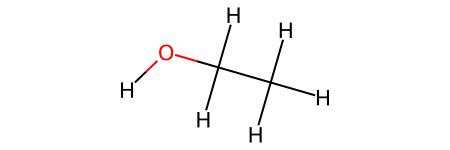

In [ ]:
mol_h = Chem.AddHs(mol) # add hydrogen back
mol_h

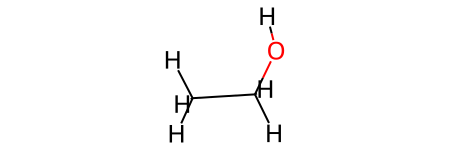

In [ ]:
AllChem.EmbedMolecule(mol_h, AllChem.ETKDG()) #embed 2D into 3D structure
AllChem.UFFOptimizeMolecule(mol_h) # optimize the 3D structure
mol_h


#### Writing into an XYZ file

In [ ]:
xyz = Chem.MolToXYZBlock(mol_h)
print(xyz)

# write to a file
with open("rdkit_prac/ethanol.xyz", "w") as f: # this is how you write strings into a file with python
    f.write(xyz)

9

O      1.140493    0.874279   -0.632915
C      0.626989   -0.188338    0.122960
C     -0.884070   -0.280679   -0.050352
H      0.925229    1.706364   -0.135750
H      0.879097   -0.059889    1.200083
H      1.091067   -1.133878   -0.228711
H     -1.275201   -1.143169    0.529385
H     -1.135644   -0.423328   -1.122688
H     -1.367959    0.648639    0.317987



## Functional group detection with SMARTS

Starting from a hydroxyl group -OH

In [ ]:
hydroxyl_smarts = "[OX2H]" # X2 after O means O has exactly 2 connections
hydroxyl = Chem.MolFromSmarts(hydroxyl_smarts) # we still need a mol object with rdkit

In [ ]:
test_smiles = ["CCO", "CC", "CC(=O)O", "c1ccccc1"]
for s in test_smiles:
    m = Chem.MolFromSmiles(s)
    print(s, m.HasSubstructMatch(hydroxyl))


CCO True
CC False
CC(=O)O True
c1ccccc1 False


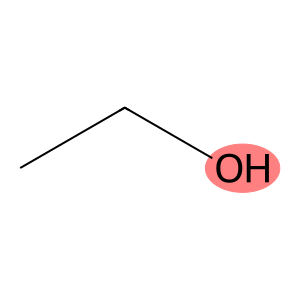

In [ ]:
# we can also highlight the match
matches = mol.GetSubstructMatches(hydroxyl) # remember mol is the ethnol from previous lines
Draw.MolToImage(mol, highlightAtoms=[i for match in matches for i in match])

### Now let's do a serious data analysis

I am providing you 1000 SMILES strings from the QM9 dataset.

Let's make a histogram of different functional groups in the molecules.

In [ ]:
!wget -q "https://raw.githubusercontent.com/SunLab-Rutgers/chem542_CDS/refs/heads/main/labs/lab2/data/smiles_1000_clean.csv" -O rdkit_prac/smiles_1000.csv

In [ ]:
# import our old friends
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
# load the csv file
df = pd.read_csv("rdkit_prac/smiles_1000.csv", index_col=False)
df.head()

,filename,smiles
0,dsgdb9nsd_035176,N#C[C@H]1N[C@]12[C@@H]1C[C@H]2C1
1,dsgdb9nsd_131462,O=COc1nonc1O
2,dsgdb9nsd_073123,C[C@]12CC[C@H]1C[N@]1C[C@H]12
3,dsgdb9nsd_096811,C/N=C1\OC(=O)C[C@H]1N
4,dsgdb9nsd_100867,C[C@@H](CO)[C@H](C#N)CO


In [ ]:
functional_groups = {
    "Alcohol": "[OX2H]",
    "Amine": "[NX3;H2,H1,H0;!$(NC=O)]",
    "Carbonyl": "[CX3]=O",
    "Carboxylic acid": "C(=O)[OX2H1]",
    "Ester": "C(=O)O[C;!H0]",
    "Ether": "[OD2]([#6])[#6]",
    "Nitrile": "C#N",
    "Halogen": "[F,Cl,Br,I]",
    "Aromatic ring": "a"
}

In [ ]:
fg_counts = {fg: 0 for fg in functional_groups}

for smi in df["smiles"]:
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        continue
    for fg, smarts in functional_groups.items():
        patt = Chem.MolFromSmarts(smarts)
        if mol.HasSubstructMatch(patt):
            fg_counts[fg] += 1


[01:12:57] WARNING: not removing hydrogen atom without neighbors
[01:12:57] WARNING: not removing hydrogen atom without neighbors
[01:12:57] WARNING: not removing hydrogen atom without neighbors
[01:12:57] WARNING: not removing hydrogen atom without neighbors


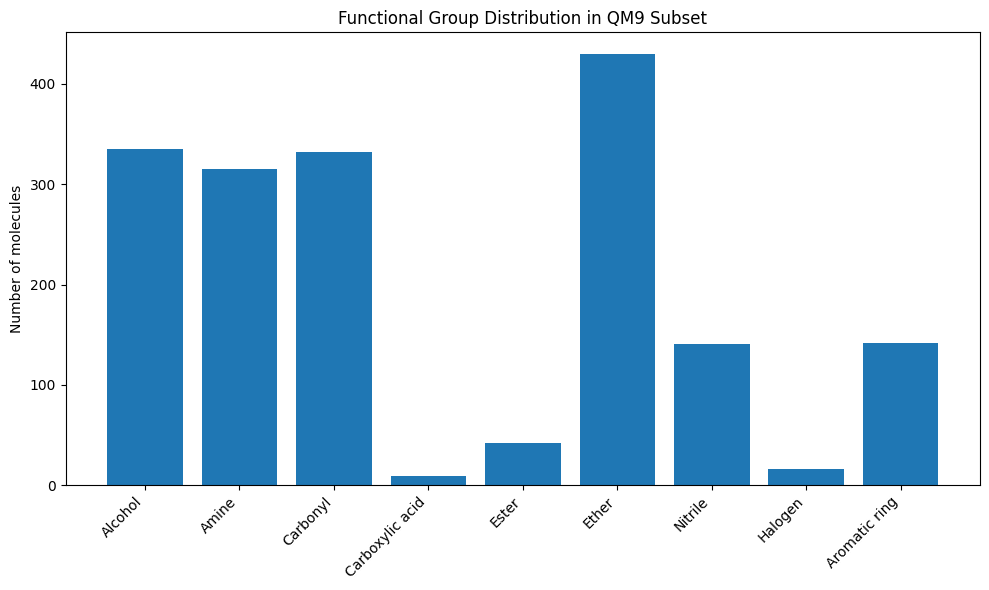

In [ ]:
plt.bar(fg_counts.keys(), fg_counts.values())
plt.xticks(rotation=45, ha="right")
plt.ylabel("Number of molecules")
plt.title("Functional Group Distribution in QM9 Subset")
plt.tight_layout()
plt.show()

## Extra: using py3Dmol for prettier visualization

In [ ]:
!pip -q install py3Dmol

In [ ]:
from rdkit import Chem
from rdkit.Chem import AllChem
import py3Dmol

In [ ]:
# 1. create an RDKit molecule
smiles = "CC(=O)Oc1ccccc1C(=O)O"  # Aspirin
mol = Chem.MolFromSmiles(smiles)

In [ ]:
# add hydrogen and generate the 3D structure
mol_h = Chem.AddHs(mol)
AllChem.EmbedMolecule(mol_h, AllChem.ETKDG())
AllChem.UFFOptimizeMolecule(mol_h)
# Get MolBlock (RDKit's internal 3D format)
molblock = Chem.MolToMolBlock(mol_h)

In [ ]:
# Visualize with py3Dmol
view = py3Dmol.view(width=400, height=400)
view.addModel(molblock, 'mol')  # 'mol' indicates MolBlock format
view.setStyle({'stick':{}})
# view.setBackgroundColor('0xeeeeee')
view.zoomTo()
view.show()

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

### Save to files

In [ ]:
# save the figure to an html file
html_str = view._make_html()
with open("molecule.html", "w") as f:
    f.write(html_str)

### Visualizing an xyz file

In [ ]:
!wget -q "https://raw.githubusercontent.com/SunLab-Rutgers/chem542_CDS/refs/heads/main/labs/lab2/data/methane.xyz" -O methane.xyz

In [ ]:
# 1. Read XYZ file
with open("methane.xyz", "r") as f:
    xyz_str = f.read()

In [ ]:
# 2. Create py3Dmol view
view = py3Dmol.view(width=400, height=400)
view.addModel(xyz_str, "xyz")  # Specify 'xyz' format
# view.setStyle({'stick': {}})   # Show sticks
view.setStyle({'stick':{}, 'sphere':{'scale':0.3}}) # adding sphere to make the ball-and-stick style
view.zoomTo()
view.show()

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

#